libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# PART A

random vectors

In [2]:
rng = np.random.default_rng()

# Data points
X1 = rng.random(5)
X1 = 5*X1
X1.sort()
Y1 = rng.random(5)
Y1 = 5*Y1

using least squares

In [3]:
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X1, np.ones(len(X1))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y1, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

Slope: -0.9957550593272295, Intercept: 3.746220002214635


plotting

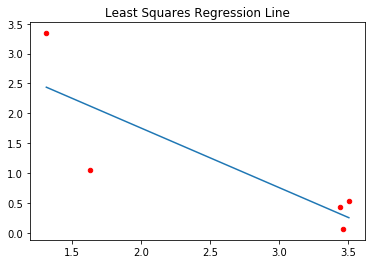

In [4]:
plt.scatter(X1,Y1,20,"r")
plt.plot(X1,m*X1+c)
plt.title("Least Squares Regression Line")
plt.show()

evaluation MSE and R-squared for least squares

In [5]:
# Mean Squared Error (MSE)
mselsq = np.mean((Y1 - (m*X1+c))**2)
print(f'Mean Squared Error: {mselsq:.4f}')
# R-squared value
ss_total = np.sum((Y1 - np.mean(Y1))**2)
ss_res = np.sum((Y1 - (m*X1+c))**2)
r_squaredlsq = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredlsq:.4f}')

Mean Squared Error: 0.4197
R-squared: 0.6954


using polynomial fit

In [6]:
# Polynomial fitting using NumPy's polyfit
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(X1, Y1, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,5,50)
y_pred = polynomial(x)

Polynomial Coefficients:  [ -0.59661987   6.98151027 -23.8578205   23.99597834]


plotting

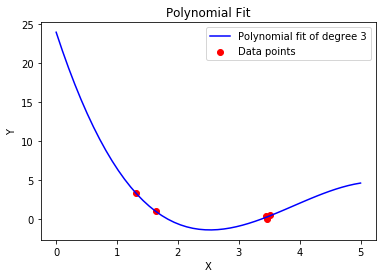

In [7]:
# Step 4: Plotting the results
plt.scatter(X1, Y1, color='red', label='Data points') # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (cubic) fit

In [8]:
# Mean Squared Error (MSE)
msecub = np.mean((Y1 - polynomial(X1))**2)
print(f'Mean Squared Error: {msecub:.4f}')
# R-squared value
ss_total = np.sum((Y1 - np.mean(Y1))**2)
ss_res = np.sum((Y1 - polynomial(X1))**2)
r_squaredcub = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredcub:.4f}')

Mean Squared Error: 0.0209
R-squared: 0.9849


which one is better

In [9]:
if msecub < mselsq and r_squaredcub > r_squaredlsq:
    print("Polynomial fit is the better model.")
elif mselsq < msecub and r_squaredlsq > r_squaredcub:
    print("Linear least squares is the better model.")
else:
    print("Both models perform similarly.")

Polynomial fit is the better model.


# PART B

using new data set (random line with perterbation) so that the effect can be seen better

In [10]:
truem = 3 * rng.random() + 2
truec = 3 * rng.random() + 2

print(f"true m: {truem}")
print(f"true c: {truec}")

X = np.arange(0,1,.04)
rand = rng.random(25)
rand = 2*(rand-0.5)
Y = truem*X+truec+2*rand

true m: 4.666549058705018
true c: 4.713225391581734


using least squares

In [11]:
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

Slope: 5.4098932687054315, Intercept: 4.26666508528775


plotting

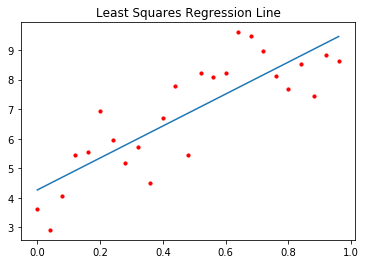

In [12]:
plt.scatter(X,Y,10,"r")
plt.plot(X,m*X+c)
plt.title("Least Squares Regression Line")
plt.show()

evaluation MSE and R-squared for least squares

In [13]:
# Mean Squared Error (MSE)
mselsq = np.mean((Y - (m*X+c))**2)
print(f'Mean Squared Error: {mselsq:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - (m*X+c))**2)
r_squaredlsq = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredlsq:.4f}')

Mean Squared Error: 1.0589
R-squared: 0.6969


using polynomial fit of degree 3

In [14]:
# Polynomial fitting using NumPy's polyfit
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-8.04908669  5.35967645  7.03098811  3.6622546 ]


plotting

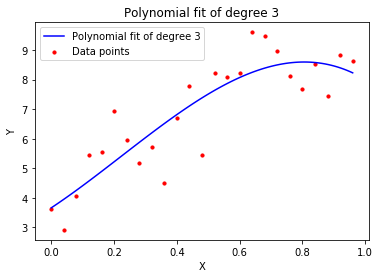

In [15]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (cubic) fit

In [16]:
# Mean Squared Error (MSE)
msecub = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msecub:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredcub = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredcub:.4f}')

Mean Squared Error: 0.8223
R-squared: 0.7646


using polynomial fit of degree 4

In [17]:
# Polynomial fitting using NumPy's polyfit
degree = 4 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-26.89351911  43.58647    -26.0949835   13.43379714   3.41142972]


plotting

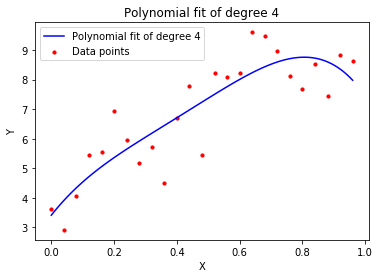

In [18]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 4) fit

In [19]:
# Mean Squared Error (MSE)
msefour = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msefour:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredfour = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredfour:.4f}')

Mean Squared Error: 0.8067
R-squared: 0.7691


using polynomial fit of degree 5

In [20]:
# Polynomial fitting using NumPy's polyfit
degree = 5 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [ 376.6618995  -930.88207792  807.95901806 -293.67559691   47.36655452
    2.63076931]


plotting

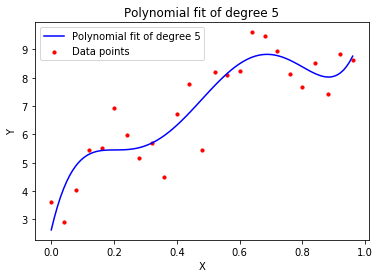

In [21]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 5) fit

In [22]:
# Mean Squared Error (MSE)
msefive = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msefive:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredfive = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredfive:.4f}')

Mean Squared Error: 0.6209
R-squared: 0.8223


using polynomial fit of degree 6

In [23]:
# Polynomial fitting using NumPy's polyfit
degree = 6 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [  932.9521815  -2310.24038321  1980.60723903  -655.01856424
    42.36935498    18.55160216     3.03155482]


plotting

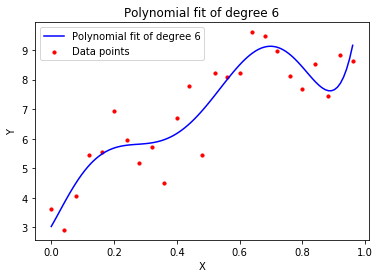

In [24]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 6) fit

In [25]:
# Mean Squared Error (MSE)
msesix = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msesix:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredsix = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredsix:.4f}')

Mean Squared Error: 0.5533
R-squared: 0.8416


using polynomial fit of degree 7

In [26]:
# Polynomial fitting using NumPy's polyfit
degree = 7 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-5.71555064e+03  2.01372023e+04 -2.77090923e+04  1.86912594e+04
 -6.32785988e+03  9.66255738e+02 -3.80978803e+01  3.50751201e+00]


plotting

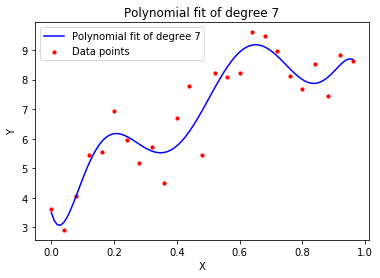

In [27]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 7) fit

In [28]:
# Mean Squared Error (MSE)
mseseven = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {mseseven:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredseven = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredseven:.4f}')

Mean Squared Error: 0.4065
R-squared: 0.8837


using polynomial fit of degree 8

In [29]:
# Polynomial fitting using NumPy's polyfit
degree = 8 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [ 3.64983936e+03 -1.97309338e+04  4.20315667e+04 -4.55568418e+04
  2.67765147e+04 -8.32531055e+03  1.20950696e+03 -4.92395024e+01
  3.56262591e+00]


plotting

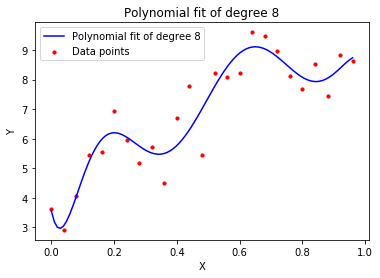

In [30]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 8) fit

In [31]:
# Mean Squared Error (MSE)
mseeight = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {mseeight:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredeight = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredeight:.4f}')

Mean Squared Error: 0.4031
R-squared: 0.8846


using polynomial fit of degree 9

In [32]:
# Polynomial fitting using NumPy's polyfit
degree = 9 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-4.02295157e+04  1.77441347e+05 -3.32941851e+05  3.46977732e+05
 -2.19033146e+05  8.49451905e+04 -1.93255872e+04  2.25303783e+03
 -8.63371804e+01  3.66554024e+00]


plotting

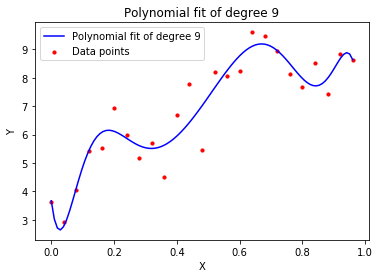

In [33]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 9) fit

In [34]:
# Mean Squared Error (MSE)
msenine = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msenine:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squarednine = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squarednine:.4f}')

Mean Squared Error: 0.3807
R-squared: 0.8910


using polynomial fit of degree 10

In [35]:
# Polynomial fitting using NumPy's polyfit
degree = 10 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-5.90448491e+04  2.43185760e+05 -4.01471645e+05  3.22910930e+05
 -1.03138924e+05 -2.72011907e+04  3.49579509e+04 -1.18076458e+04
  1.67816230e+03 -6.98865093e+01  3.64169066e+00]


plotting

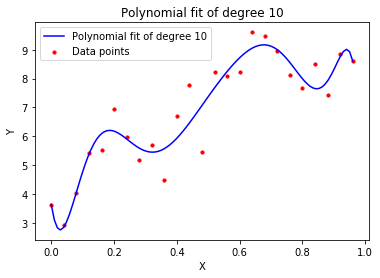

In [36]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 10) fit

In [37]:
# Mean Squared Error (MSE)
mseten = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {mseten:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredten = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredten:.4f}')

Mean Squared Error: 0.3782
R-squared: 0.8918


using polynomial fit of degree 11

In [38]:
# Polynomial fitting using NumPy's polyfit
degree = 11 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [ 6.80502149e+05 -3.65209619e+06  8.44731967e+06 -1.10081592e+07
  8.85996765e+06 -4.53262818e+06  1.45569674e+06 -2.76434268e+05
  2.66143464e+04 -7.62649673e+02 -1.16328153e+01  3.60137632e+00]


plotting

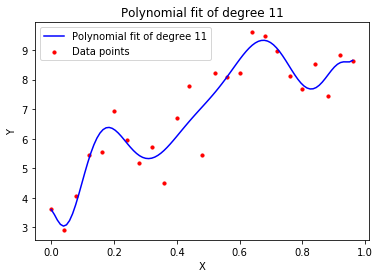

In [39]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 11) fit

In [40]:
# Mean Squared Error (MSE)
mseeleven = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {mseeleven:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredeleven = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredeleven:.4f}')

Mean Squared Error: 0.3612
R-squared: 0.8966


using polynomial fit of degree 12

In [41]:
# Polynomial fitting using NumPy's polyfit
degree = 12 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-4.16462003e+04  9.20384263e+05 -4.25762760e+06  9.32734632e+06
 -1.18215763e+07  9.35846731e+06 -4.73746519e+06  1.51148125e+06
 -2.86152344e+05  2.76245858e+04 -8.17436734e+02 -1.05051203e+01
  3.60104163e+00]


plotting

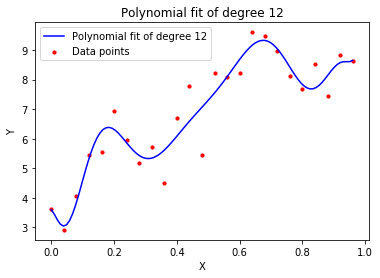

In [42]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 12) fit

In [43]:
# Mean Squared Error (MSE)
msetwelve = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msetwelve:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredtwelve = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredtwelve:.4f}')

Mean Squared Error: 0.3612
R-squared: 0.8966


using polynomial fit of degree 13

In [44]:
# Polynomial fitting using NumPy's polyfit
degree = 13 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-2.78074795e+07  1.73477026e+08 -4.78939719e+08  7.70340829e+08
 -7.99692072e+08  5.60846318e+08 -2.70372752e+08  8.94390674e+07
 -1.99365326e+07  2.88991969e+06 -2.57087961e+05  1.26889592e+04
 -2.57456491e+02  3.62893069e+00]


plotting

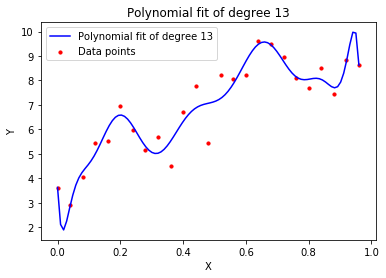

In [45]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 13) fit

In [46]:
# Mean Squared Error (MSE)
msenine = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msenine:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squarednine = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squarednine:.4f}')

Mean Squared Error: 0.2987
R-squared: 0.9145


using polynomial fit of degree 14

In [47]:
# Polynomial fitting using NumPy's polyfit
degree = 14 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-4.42981769e+07  2.69876270e+08 -7.21613911e+08  1.11029460e+09
 -1.08133864e+09  6.88458479e+08 -2.83155276e+08  6.93363098e+07
 -6.79074904e+06 -1.18638914e+06  4.79826159e+05 -6.69379998e+04
  4.62914106e+03 -1.23357958e+02  3.62386270e+00]


plotting

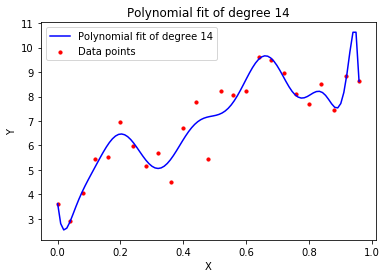

In [48]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 14) fit

In [49]:
# Mean Squared Error (MSE)
msefourteen = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msefourteen:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredfourteen = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredfourteen:.4f}')

Mean Squared Error: 0.2919
R-squared: 0.9165


using polynomial fit of degree 15

In [50]:
# Polynomial fitting using NumPy's polyfit
degree = 15 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-8.74196871e+07  5.85123573e+08 -1.77475568e+09  3.23908400e+09
 -3.98448178e+09  3.50483613e+09 -2.27752757e+09  1.10938745e+09
 -4.04582051e+08  1.08647690e+08 -2.08073160e+07  2.70914312e+06
 -2.24515836e+05  1.07045506e+04 -2.17044776e+02  3.62489760e+00]


plotting

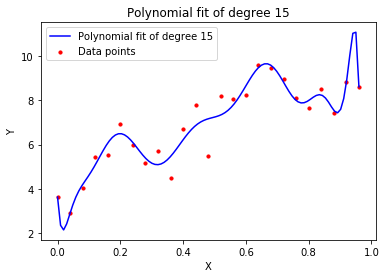

In [51]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 15) fit

In [52]:
# Mean Squared Error (MSE)
msefifteen = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msefifteen:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredfifteen = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredfifteen:.4f}')

Mean Squared Error: 0.2908
R-squared: 0.9168


using polynomial fit of degree 16

In [53]:
# Polynomial fitting using NumPy's polyfit
degree = 16 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-2.41181695e+09  1.84353354e+10 -6.40627799e+10  1.33924154e+11
 -1.87819260e+11  1.86546950e+11 -1.35019847e+11  7.21744142e+10
 -2.85664298e+10  8.31555800e+09 -1.75158658e+09  2.59651630e+08
 -2.59058832e+07  1.61528387e+06 -5.47627490e+04  7.31284829e+02
  3.62223985e+00]


plotting

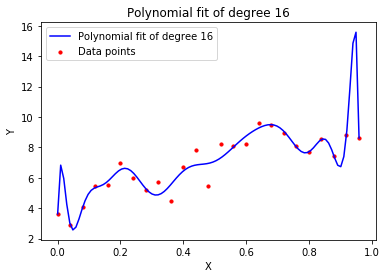

In [54]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 16) fit

In [55]:
# Mean Squared Error (MSE)
msesixteen = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msesixteen:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredsixteen = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredsixteen:.4f}')

Mean Squared Error: 0.2609
R-squared: 0.9253


MSE decreases and R-squared increases with a higher polynomial, but the prediction is less useful because it is overfit. From the plots the function can be seen to fit the noise of the data, not the trend.

# PART C

creating vandermonde matrix

In [56]:
# Create Vandermonde matrix for a polynomial of degree 3
degree = 3
V = np.vander(X1, N=degree+1, increasing=True)

using vandermonde matrix

In [57]:
# V.T * V
VT_V = np.dot(V.T, V)

# V.T * y
VT_y = np.dot(V.T, Y1)

# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)

# Generate polynomial function based on the coefficients
x = np.linspace(0,5,50)
polynomial = np.poly1d(coefficients[::-1])  # reverse the order
y_pred = polynomial(x)

plotting

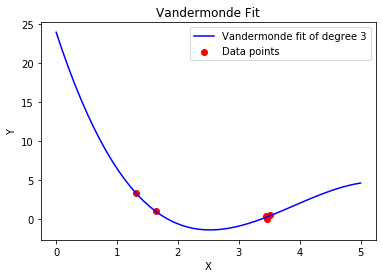

In [58]:
# Plotting the results
plt.scatter(X1, Y1, color='red', label='Data points') # Original data points
plt.plot(x, y_pred, color='blue', label=f'Vandermonde fit of degree {degree}')
plt.title('Vandermonde Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()